# **Lecture 20: Solving PDEs II - Wave Equation, Stability, & Libraries**
**Date:** Thursday, 19-02-2026
**Unit:** 2 (Differential Equations)
**Topic:** The Wave Equation, the CFL Condition, and using `scipy.integrate` for PDEs

---

## **1. The Physics of the Wave Equation**

In Lecture 19, we modeled heat, which *diffuses* and smooths out. Today we model **Waves**, which *propagate* and retain their shape.

The 1D Wave Equation is a **Hyperbolic PDE**:
$$\frac{\partial^2 u}{\partial t^2} = c^2 \frac{\partial^2 u}{\partial x^2}$$

Where:
* $u(x, t)$ is the displacement (e.g., height of a water wave, pressure of a sound wave, or amplitude of a gravitational wave).
* $c$ is the wave speed (e.g., speed of sound $c_s$, or speed of light $c$).

Notice that it has a **second derivative in time**, meaning the system has "inertia." To solve it, we need **two** initial conditions:
1.  Initial Position: $u(x, 0)$
2.  Initial Velocity: $\frac{\partial u}{\partial t}(x, 0)$

## **2. The Danger of Explicit Methods: The CFL Condition**

If we discretize the wave equation using our standard Central Difference formulas for both space and time, we get:
$$\frac{u_i^{n+1} - 2u_i^n + u_i^{n-1}}{\Delta t^2} = c^2 \frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta x^2}$$

Solving for the future time step $u_i^{n+1}$, we can march forward in time. However, there is a physical speed limit to this math.

### **The Courant-Friedrichs-Lewy (CFL) Condition**
Define the **Courant Number** $C$:
$$C = \frac{c \Delta t}{\Delta x}$$

For the simulation to be stable, we **MUST** satisfy:
$$C \le 1 \implies \Delta t \le \frac{\Delta x}{c}$$

**The Physical Intuition:**
Imagine taking photographs of a moving car to measure its speed. If your camera shutter is too slow (large $\Delta t$), the car moves entirely out of the frame before the next picture.
In our grid, information travels at speed $c$. If $c \Delta t$ (the distance the wave travels in one time step) is larger than $\Delta x$ (the distance between our grid points), the wave "jumps" over our grid points. The math misses the wave, feedback loops occur, and the simulation explodes to infinity.

## **3. The Professional Approach: The Method of Lines (MOL)**

Writing explicit nested `for` loops and constantly worrying about the CFL condition is exhausting and prone to errors.
In professional Computational Astrophysics, we use **Predefined Library Solvers** (like `scipy.integrate.solve_ivp`).

But `solve_ivp` only solves ODEs (1D time), not PDEs (Time + Space). How do we feed a PDE into an ODE solver? We use the **Method of Lines (MOL)**.

### **Step 1: Discretize Space, but NOT Time**
Instead of a 2D grid of space and time, imagine $N$ individual points on a string. Each point $i$ is allowed to move up and down continuously in time.
We replace only the spatial derivative with finite differences:

$$\frac{d^2 u_i}{dt^2} = c^2 \frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta x^2}$$

**Magic:** This is no longer a PDE! It is a system of $N$ coupled Ordinary Differential Equations (ODEs).

### **Step 2: Reduce to First-Order ODEs**
Library solvers only accept first-order ODEs. We define a new variable for velocity: $v_i = \frac{du_i}{dt}$.
Now, every point $i$ on the string has two equations:
1.  $\frac{du_i}{dt} = v_i$
2.  $\frac{dv_i}{dt} = c^2 \frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta x^2}$

## **4. Python Implementation using `scipy.integrate`**

Let's simulate a Gaussian wave pulse travelling on a string using `scipy.integrate.solve_ivp`.

Solving PDE using Method of Lines and solve_ivp...
Simulation Complete!


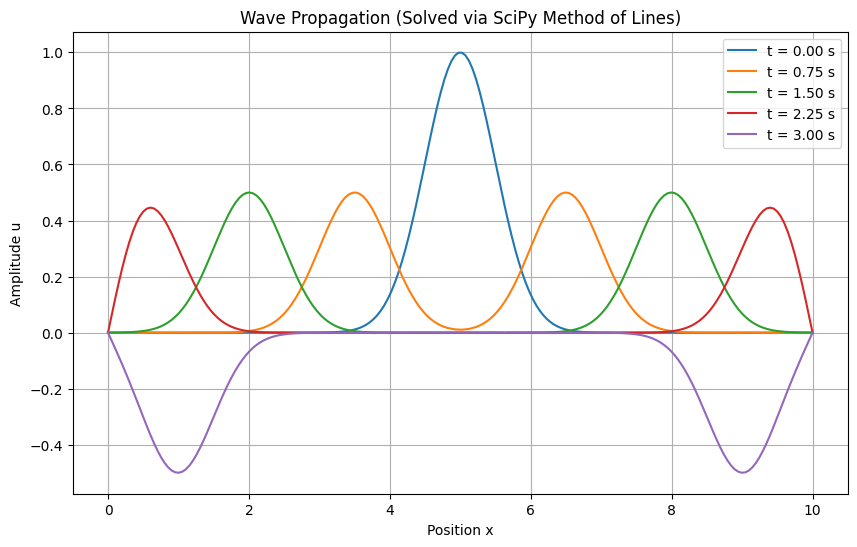

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1. Setup the Spatial Grid
L = 10.0           # Length of the string
N = 200            # Number of spatial points
x = np.linspace(0, L, N)
dx = x[1] - x[0]
c = 2.0            # Wave speed

# 2. Define the System of ODEs (The "Method of Lines" Function)
def wave_equation_mol(t, y):
    """
    y is a combined vector of length 2N: [u_0, u_1... u_N, v_0, v_1... v_N]
    We must return dy/dt: [du_0/dt... du_N/dt, dv_0/dt... dv_N/dt]
    """
    # Split the incoming vector y into u (position) and v (velocity)
    u = y[:N]
    v = y[N:]

    # Initialize output arrays
    dudt = np.zeros(N)
    dvdt = np.zeros(N)

    # 1st Eq: The derivative of position is velocity
    dudt[:] = v[:]

    # 2nd Eq: The derivative of velocity is the spatial curvature (Wave Eq)
    # We use array slicing for the interior points
    dvdt[1:-1] = (c**2 / dx**2) * (u[2:] - 2*u[1:-1] + u[:-2])

    # Boundary Conditions (Fixed ends: ends don't move, so velocity is 0)
    dvdt[0] = 0.0
    dvdt[-1] = 0.0

    # Combine dudt and dvdt back into a single 2N-length vector to return
    return np.concatenate((dudt, dvdt))

# 3. Set Initial Conditions
u_initial = np.exp(-2.0 * (x - 5.0)**2)  # A Gaussian bump in the middle
v_initial = np.zeros(N)                  # Released from rest

# Combine u and v into a single state vector
y0 = np.concatenate((u_initial, v_initial))

# 4. Solve using Scipy!
t_span = (0, 3.0)  # Simulate from t=0 to t=3 seconds
t_eval = np.linspace(0, 3.0, 5)  # We want to extract 5 specific frames to plot

print("Solving PDE using Method of Lines and solve_ivp...")
# We use 'RK45' (Runge-Kutta 4th/5th order) with adaptive step sizing.
# Scipy automatically adjusts dt to maintain stability, effectively handling the CFL condition for us!
solution = solve_ivp(wave_equation_mol, t_span, y0, method='RK45', t_eval=t_eval)
print("Simulation Complete!")

# 5. Plotting the results
plt.figure(figsize=(10, 6))

# solution.y has shape (2N, len(t_eval)).
# The top half (indices 0 to N-1) contains the u (position) data.
for j in range(len(solution.t)):
    u_at_time_t = solution.y[:N, j]
    plt.plot(x, u_at_time_t, label=f"t = {solution.t[j]:.2f} s")

plt.title("Wave Propagation (Solved via SciPy Method of Lines)")
plt.xlabel("Position x")
plt.ylabel("Amplitude u")
plt.legend()
plt.grid(True)
plt.show()


### **Why is this so powerful?**
1. **No Manual CFL Calculations:** The `solve_ivp` engine uses adaptive time-stepping. If the spatial curvature gets wild, the library automatically shrinks $\Delta t$ to stay stable.
2. **Highly Optimized:** Fortran-backed Runge-Kutta algorithms are vastly superior in error control compared to our simple manual FTCS loops.
3. **Extensible:** If you want to add friction (e.g., $-\gamma v_i$ to the $dv/dt$ equation), you just add a single term to the Python function, and SciPy handles the complex integration.

## **5. Student Exercises**

### **Exercise 1: The Expanding Supernova Shockwave (Changing Initial Conditions)**
In the code above, the wave split into two smaller waves traveling left and right. This happens because the initial velocity was zero (released from rest).

To simulate a directed shockwave moving purely to the **right**, we must give the initial pulse a specific initial velocity profile:
$v_{initial} = c \frac{\partial u_{initial}}{\partial x}$

**Task:**
1. Calculate the analytical derivative $\frac{\partial u}{\partial x}$ of the initial Gaussian pulse $u = e^{-2(x-5)^2}$.
2. Modify the `v_initial` array in the code block above to match this derivative multiplied by $c$.
3. Run the code and observe the wave traveling purely in one direction.

---

### **Exercise 2: Periodic Boundary Conditions**
Currently, our string is tied down at the ends (`dvdt[0] = 0` and `dvdt[-1] = 0`), which causes the waves to invert and reflect.

In cosmology or fluid dynamics, we often use **Periodic Boundary Conditions**—meaning if a wave leaves the right side of the box, it seamlessly re-enters on the left side (like a Pac-Man screen).

**Task:** Modify the spatial curvature calculation in the `wave_equation_mol` function to implement periodic boundaries.
*Hint: For the point at $i=0$, its left neighbor is $i=N-1$. For the point at $i=N-1$, its right neighbor is $i=0$.*

In [2]:
# Student Code Area
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Copy the simulation code here and modify it for Exercise 1 or 2
